In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Full pipeline for Remaining Useful Life (RUL) prediction on C‑MAPSS FD001.

Implements:
  • Standardization + optional per‑unit exponential smoothing
  • Sliding windows with RUL capped at 125 (scaled to [0,1])
  • Two models: (a) LSTM baseline, (b) Dual-Attention LSTM (DA‑LSTM)
  • SmoothL1 loss with mild late‑life weighting
  • 5‑step weighted averaging at inference (paper’s Eq.25)

Switch MODEL = "baseline" or "dalstm" below.
"""

# -----------------------------
# 0) Environment (Colab)
# -----------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass  # Running locally

import os, random
import numpy as np
import pandas as pd
from sklearn import preprocessing

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# 1) Reproducibility & Config
# -----------------------------
SEED        = 2025
FD_ID       = '1'              # '1','2','3','4'
DATA_DIR    = '/content/drive/MyDrive/c-mapss'   # <-- change if needed
MODEL       = 'baseline'       # 'baseline' or 'dalstm'

BATCH_SZ    = 32
SEQ_LEN     = 30
EPOCHS      = 40
LR          = 1e-3
WEIGHT_DECAY= 1e-4
SMOOTH_RATE = 30               # 30 for FD001 is common; try 10 or 0 too
T_CP        = 20           # RUL cap

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Sensor subset often used for FD001
SENSOR_COLS = ['s2','s3','s4','s7','s8','s9',
               's11','s12','s13','s14','s15','s17','s20','s21']

# -----------------------------
# 2) Helpers
# -----------------------------
def exponential_smoothing(x, smooth_rate=30):
    """Simple exponential smoothing with gamma = 2/(1+s)."""
    if smooth_rate is None or smooth_rate <= 0:
        return x.astype(np.float32)
    gamma = 2.0 / (1.0 + smooth_rate)
    out = np.zeros_like(x, dtype=np.float32)
    out[0] = x[0]
    for t in range(1, len(x)):
        out[t] = gamma * x[t] + (1.0 - gamma) * out[t-1]
    return out

def weighted_average_rul(preds, delta=0.2):
    """5‑step equal‑weight smoothing (paper’s Eq. 25 with 0.2 weights)."""
    smoothed = []
    for k in range(len(preds)):
        s = max(0, k-4)
        w = np.full(k-s+1, delta, dtype=np.float32)
        smoothed.append(np.sum(w * preds[s:k+1]) / w.sum())
    return np.array(smoothed, dtype=np.float32)

def rmse(yhat, y):
    return float(np.sqrt(np.mean((yhat - y) ** 2)))

def score_metric(yhat, y, a1=10, a2=13):
    d = yhat - y
    s = np.where(d < 0, np.exp(-d / a1) - 1, np.exp(d / a2) - 1)
    return float(np.sum(s))

# -----------------------------
# 3) Data loader
# -----------------------------
class CMAPSSLoader:
    """Load & preprocess one FD subset (standardize + optional smoothing)."""
    def __init__(self, fd_id='1', smooth_rate=30):
        self.fd_id = fd_id
        self.smooth_rate = smooth_rate
        self.train_df, self.test_df, self.truth_df = self._import()

    def _import(self):
        def _read_tt(name):  # train/test only
            f = os.path.join(DATA_DIR, f'{name}_FD00{self.fd_id}.txt')
            df = pd.read_csv(f, sep=r'\s+', header=None)
            # Some copies have extra blank columns; keep first 26
            if df.shape[1] > 26:
                df = df.iloc[:, :26]
            df.columns = (['id','cycle','setting1','setting2','setting3'] +
                          [f's{i}' for i in range(1,22)])
            return df

        train = _read_tt('train')
        test  = _read_tt('test')

        # RUL file: single column
        f_rul = os.path.join(DATA_DIR, f'RUL_FD00{self.fd_id}.txt')
        truth = pd.read_csv(f_rul, sep=r'\s+', header=None, names=['more'])

        # Keep selected sensors
        train = train[['id','cycle'] + SENSOR_COLS].copy()
        test  = test [['id','cycle'] + SENSOR_COLS].copy()

        # Standardize per sensor using train stats
        scaler = preprocessing.StandardScaler()
        train[SENSOR_COLS] = scaler.fit_transform(train[SENSOR_COLS].values)
        test [SENSOR_COLS] = scaler.transform   (test [SENSOR_COLS].values)

        # Per-unit exponential smoothing
        if self.smooth_rate and self.smooth_rate > 0:
            for col in SENSOR_COLS:
                train[col] = train.groupby('id')[col].transform(
                    lambda x: exponential_smoothing(x.values, self.smooth_rate))
                test[col] = test.groupby('id')[col].transform(
                    lambda x: exponential_smoothing(x.values, self.smooth_rate))

        # Build truth table: max cycle per test unit + provided RUL
        truth['id'] = truth.index + 1
        mx = test.groupby('id')['cycle'].max().reset_index().rename(columns={'cycle':'max'})
        truth = truth.merge(mx, on='id', how='left')
        truth['max'] = truth['max'] + truth['more']
        truth.drop(columns=['more'], inplace=True)

        return train, test, truth

    def get_train_units(self):
        """Return list of [signals(14,T), time(T,), T_max] per train unit."""
        units = self.train_df['id'].unique()
        out = []
        for uid in units:
            sub = self.train_df[self.train_df['id']==uid]
            signal = sub[SENSOR_COLS].values.T.astype(np.float32)  # (14, T)
            time   = sub['cycle'].values.astype(np.int32)
            out.append([signal, time, time.max()])
        return out

    def get_test_units(self):
        units = self.test_df['id'].unique()
        out = []
        for uid in units:
            sub = self.test_df[self.test_df['id']==uid]
            signal = sub[SENSOR_COLS].values.T.astype(np.float32)
            time   = sub['cycle'].values.astype(np.int32)
            T_max  = self.truth_df[self.truth_df['id']==uid]['max'].values[0]
            rul    = (T_max - time).astype(np.float32)
            out.append([signal, time, T_max, rul])
        return out

# -----------------------------
# 4) Dataset (sliding windows)
# -----------------------------
class SlidingWindowDataset(Dataset):
    """
    Keep all windows; target is min(RUL, T_CP)/T_CP ∈ [0,1].
    """
    def __init__(self, units, seq_len=30, T_cp=125):
        self.samples = []
        for sgn, time, T in units:
            rul_series = T - time
            y_series = np.minimum(rul_series, T_cp).astype(np.float32) / T_cp
            # windows
            for i in range(sgn.shape[1] - seq_len + 1):
                x = sgn[:, i:i+seq_len].T                    # (L,14)
                y = y_series[i + seq_len - 1]                # scalar in [0,1]
                self.samples.append((torch.tensor(x), torch.tensor([y])))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

# -----------------------------
# 5) Models
# -----------------------------
class LSTM_Baseline(nn.Module):
    """
    Simple, strong baseline: LSTM -> MLP head.
    Returns raw (unbounded) logits; loss/eval apply sigmoid.
    """
    def __init__(self, n_sensors=14, lstm_h=16, lstm_layers=2):
        super().__init__()
        self.enc = nn.LSTM(n_sensors, lstm_h, lstm_layers, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(lstm_h, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        _, (h_n, _) = self.enc(x)  # h_n: (layers,B,H)
        h = h_n[-1]                # top layer
        y = self.head(h).squeeze(-1)
        return y                   # raw (use sigmoid outside)

class AdditiveAttention(nn.Module):
    """AEF: attention over time (Bahdanau-style)."""
    def __init__(self, q_dim, k_dim, hidden=28):
        super().__init__()
        self.Wq = nn.Linear(q_dim, hidden, bias=True)
        self.Wk = nn.Linear(k_dim, hidden, bias=True)
        self.v  = nn.Linear(hidden, 1, bias=False)
    def forward(self, q, keys, vals):
        e = self.v(torch.tanh(self.Wq(q).unsqueeze(1) + self.Wk(keys))).squeeze(-1)  # (B,T)
        a = torch.softmax(e, dim=1)
        ctx = torch.bmm(a.unsqueeze(1), vals).squeeze(1)                              # (B,H)
        return ctx, a

class FeatureAttention(nn.Module):
    """AOF: attention over sensors (features)."""
    def __init__(self, n_sensors=14, hidden=16):
        super().__init__()
        self.fc1 = nn.Linear(n_sensors, hidden)
        self.fc2 = nn.Linear(hidden, n_sensors)
    def forward(self, x):
        # x: (B, T, n)
        feat_stat = x.mean(dim=1)                            # (B,n)
        scores = self.fc2(torch.tanh(self.fc1(feat_stat)))   # (B,n)
        w = torch.softmax(scores, dim=-1)                    # (B,n)
        ctx = (x * w.unsqueeze(1)).sum(dim=1)                # (B,n) weighted over time
        return ctx, w

class DALSTM(nn.Module):
    """
    Lightweight Dual-Attention LSTM.
    Returns raw logits; loss/eval apply sigmoid.
    """
    def __init__(self, n_sensors=14, lstm_h=8, lstm_layers=2):
        super().__init__()
        self.enc = nn.LSTM(n_sensors, lstm_h, lstm_layers, batch_first=True)
        self.att_time = AdditiveAttention(lstm_h, lstm_h, hidden=28)  # AEF
        self.att_feat = FeatureAttention(n_sensors, hidden=16)        # AOF
        self.dec = nn.LSTMCell(n_sensors + lstm_h, lstm_h)
        self.fc  = nn.Sequential(nn.Linear(lstm_h, 8), nn.ReLU(), nn.Linear(8, 1))
    def forward(self, x):                              # x: (B,L,14)
        enc_out, (h_n, _) = self.enc(x)               # (B,L,H), (layers,B,H)
        h_mean = h_n.mean(dim=0)                      # (B,H)
        h_aef, _ = self.att_time(h_mean, enc_out, enc_out)  # (B,H)
        h_aof, _ = self.att_feat(x)                   # (B,14)
        dec_in = torch.cat([h_aof, h_aef], dim=-1)    # (B,14+H)
        h0, c0 = h_mean, torch.zeros_like(h_mean)
        h1, _  = self.dec(dec_in, (h0, c0))
        y = self.fc(h1).squeeze(-1)                   # raw
        return y

# -----------------------------
# 6) Loss (SmoothL1 + mild late-life weighting)
# -----------------------------
class WeightedSmoothL1(nn.Module):
    """
    weight = 1 + alpha*(1 - y), y in [0,1] (smaller y => closer to failure).
    Apply sigmoid to raw model outputs to ensure gradients (no hard clamping).
    """
    def __init__(self, alpha=1.0, beta=0.05):
        super().__init__()
        self.alpha = alpha
        self.loss = nn.SmoothL1Loss(beta=beta, reduction='none')
    def forward(self, pred_raw, target):
        pred = torch.sigmoid(pred_raw)              # map to [0,1]
        w = 1.0 + self.alpha * (1.0 - target)
        return torch.mean(w * self.loss(pred, target))

# -----------------------------
# 7) Build data
# -----------------------------
loader = CMAPSSLoader(fd_id=FD_ID, smooth_rate=SMOOTH_RATE)
train_units = loader.get_train_units()
test_units  = loader.get_test_units()

train_ds = SlidingWindowDataset(train_units, seq_len=SEQ_LEN, T_cp=T_CP)
train_dl = DataLoader(train_ds, batch_size=BATCH_SZ, shuffle=True, drop_last=True)

print(f"[Debug] #train windows: {len(train_ds)} | batch size: {BATCH_SZ}")
xb0, yb0 = next(iter(train_dl))
print(f"[Debug] batch shapes: X={xb0.shape}  y={yb0.shape}  y-range=[{yb0.min().item():.3f}, {yb0.max().item():.3f}]")

# -----------------------------
# 8) Train
# -----------------------------
model = LSTM_Baseline(n_sensors=len(SENSOR_COLS), lstm_h=64, lstm_layers=2).to(device) if MODEL=='baseline' \
        else DALSTM(n_sensors=len(SENSOR_COLS), lstm_h=8, lstm_layers=2).to(device)

criterion = WeightedSmoothL1(alpha=1.0, beta=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    for xb, yb in train_dl:
        xb = xb.to(device).float()
        yb = yb.to(device).squeeze(-1).float()
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item() * xb.size(0)
    print(f"Epoch {epoch:02d} | Loss {running/len(train_ds):.4f}")

# -----------------------------
# 9) Evaluate (per test unit) + percentage error
# -----------------------------
model.eval()
pred_last = []
true_last_cap = []     # for RMSE/Score (capped @ 125 to match training)
true_last_uncap = []   # for percentage error (numerator uses uncapped true RUL)
Ts_list = []           # lifetimes (denominator)

with torch.no_grad():
    for sgn, time, T_max, rul in test_units:
        # true RUL at the last observed cycle
        true_rul_uncap = float(rul[-1])                 # uncapped (for percentage error)
        true_rul_cap   = float(min(true_rul_uncap, T_CP))  # capped (for RMSE/Score)

        # windows over the test unit
        X = [ sgn[:, i:i+SEQ_LEN].T for i in range(sgn.shape[1]-SEQ_LEN+1) ]
        X = torch.tensor(np.stack(X), dtype=torch.float32).to(device)

        # model outputs raw logits -> sigmoid -> [0,1]
        y_hat_scaled = torch.sigmoid(model(X)).cpu().numpy()
        y_hat = weighted_average_rul(y_hat_scaled) * T_CP

        pred_last.append(y_hat[-1])
        true_last_cap.append(true_rul_cap)
        true_last_uncap.append(true_rul_uncap)
        Ts_list.append(float(T_max))                    # lifetime of the unit

pred_last       = np.array(pred_last)
true_last_cap   = np.array(true_last_cap)
true_last_uncap = np.array(true_last_uncap)
Ts_list         = np.array(Ts_list)

# Standard metrics (with capped ground truth to match training)
print('\nFinal Metrics on FD001 (RUL capped at 125 for RMSE/SCORE)')
print('RMSE  :', rmse(pred_last, true_last_cap))
print('SCORE :', score_metric(pred_last, true_last_cap))

# Your percentage error metric (uncapped numerator, lifetime denominator)
pct_error = np.mean(np.abs(pred_last - true_last_uncap) / Ts_list)

# If you instead want to use capped RUL in the numerator, uncomment:
# pct_error = np.mean(np.abs(pred_last - true_last_cap) / Ts_list)

print('Percentage error (avg |pred - true| / lifetime):', float(pct_error))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Debug] #train windows: 17731 | batch size: 32
[Debug] batch shapes: X=torch.Size([32, 30, 14])  y=torch.Size([32, 1])  y-range=[0.200, 1.000]
Epoch 01 | Loss 0.0712
Epoch 02 | Loss 0.0248
Epoch 03 | Loss 0.0151
Epoch 04 | Loss 0.0124
Epoch 05 | Loss 0.0115
Epoch 06 | Loss 0.0107
Epoch 07 | Loss 0.0101
Epoch 08 | Loss 0.0088
Epoch 09 | Loss 0.0089
Epoch 10 | Loss 0.0083
Epoch 11 | Loss 0.0084
Epoch 12 | Loss 0.0077
Epoch 13 | Loss 0.0070
Epoch 14 | Loss 0.0075
Epoch 15 | Loss 0.0068
Epoch 16 | Loss 0.0065
Epoch 17 | Loss 0.0064
Epoch 18 | Loss 0.0063
Epoch 19 | Loss 0.0062
Epoch 20 | Loss 0.0057
Epoch 21 | Loss 0.0050
Epoch 22 | Loss 0.0048
Epoch 23 | Loss 0.0055
Epoch 24 | Loss 0.0047
Epoch 25 | Loss 0.0045
Epoch 26 | Loss 0.0042
Epoch 27 | Loss 0.0044
Epoch 28 | Loss 0.0042
Epoch 29 | Loss 0.0034
Epoch 30 | Loss 0.0034
Epoch 31 | Loss 0.0036
Epoch 32 | Loss

In [9]:
print(pred_last)
print(true_last_uncap)

[20.        20.        19.999798  20.        20.        20.
 20.        20.        20.        20.        20.        20.
 20.        20.        20.        20.        20.        20.
 20.        16.905407  20.        20.        20.        19.597809
 20.        20.        20.        20.        20.        20.
  8.093645  20.        20.         6.8732524 17.805574  19.987865
 19.999998  19.999992  20.        19.999947  19.999985  13.032852
 20.        20.        20.        20.        20.        20.
 15.380167  20.        20.        20.        19.997286  20.
 20.        14.025917  20.        19.999859  20.        20.
 19.861164  20.        20.        19.920403  20.        17.010004
 20.         9.162178  20.        20.        20.        20.
 20.        20.        20.         8.835194  19.999943  20.
 20.        20.         8.996811  11.175888  20.        20.
 20.        20.        20.        20.        20.        19.965975
 19.997795  19.998306  19.99989   19.999996  20.        20.
 20.      

In [17]:
# -----------------------------
# 9c) Lifetime cost per unit
# -----------------------------
c_warning = 1.0
c_unexpected = 100.0
WARNING_LEN = 20  # cycles

costs = []
flags_unexpected = []   # 1 if unexpected failure, else 0
t_last_list = []

# Recompute per-unit predicted failure cycle using arrays we have
# pred_last       : predicted RUL at last observation (cycles)
# true_last_uncap : true RUL at last observation (cycles)
# Ts_list         : lifetime (true failure cycle)
# We also need t_last = last observed cycle for each unit.
# If you still have 'test_units', we can read it directly:

for (sgn, time, T_max, rul), yhat in zip(test_units, pred_last):
    t_last = int(time[-1])                 # last observed cycle for this unit
    true_fail_cycle = float(T_max)         # true failure cycle (lifetime)
    pred_fail_cycle = float(t_last + yhat) # predicted failure cycle

    t_last_list.append(t_last)

    if pred_fail_cycle + 20 < true_fail_cycle:
        print(pred_fail_cycle, true_fail_cycle)
        # Predicted too late -> unexpected failure at true failure time
        cost = c_unexpected + WARNING_LEN * c_warning
        flags_unexpected.append(1)
    else:
        # Predicted on-time or early -> pay fixed warning cost over 30 cycles
        cost = WARNING_LEN * c_warning
        flags_unexpected.append(0)

    costs.append(cost)

costs = np.array(costs, dtype=np.float32)
flags_unexpected = np.array(flags_unexpected, dtype=np.int32)

print("\nCost summary (c_warning=1, c_unexpected=100):")
print(f"  Mean cost per unit      : {costs.mean():.2f}")
print(f"  Median cost per unit    : {np.median(costs):.2f}")
print(f"  Total cost (all units)  : {costs.sum():.2f}")
print(f"  Unexpected failures     : {flags_unexpected.sum()} / {len(flags_unexpected)} "
      f"({100.0 * flags_unexpected.mean():.1f}%)")


51.0 143.0
69.0 147.0
145.9998016357422 195.0
126.0 188.0
118.0 189.0
125.0 198.0
180.0 251.0
186.0 261.0
75.0 166.0
212.0 288.0
103.0 180.0
237.0 341.0
215.0 290.0
66.0 153.0
96.0 159.0
133.0 197.0
185.0 215.0
155.0 222.0
168.0 205.0
59.0 150.0
150.0 243.0
68.0 193.0
96.0 195.0
160.0 206.0
178.0 255.0
191.0 261.0
163.0 258.0
165.0 193.0
70.0 156.0
145.0 175.0
57.0 179.0
192.0 231.0
74.0 163.0
172.0 266.0
166.0 193.0
93.0 208.0
98.0 170.0
94.0 153.0
164.0 258.0
141.0 218.0
133.0 250.0
180.0 263.0
114.0 208.0
167.0 247.0
252.0 286.0
175.0 227.0
91.0 199.0
91.0 148.0
74.0 175.0
172.0 246.0
88.0 186.0
151.0 181.0
132.0 243.0
157.0 263.0
108.0 201.0
92.0 179.0
121.0 164.0
153.0 223.0
93.0 210.0
192.0 230.0
54.0 152.0
130.0 199.0
76.0 172.0
88.0 183.0
197.0 313.0
263.9998779296875 329.0
153.0 188.0
109.0 217.0
117.0 234.0
154.0 216.0
141.0 180.0
117.0 214.0

Cost summary (c_warning=1, c_unexpected=100):
  Mean cost per unit      : 92.00
  Median cost per unit    : 120.00
  Total cost (all u

In [11]:
# -----------------------------
# 9b) Grouped results with bootstrap standard errors
#     T-N: true RUL (uncapped) at prediction time ≤ N
# -----------------------------
import numpy as np

def group_metrics_with_se(pred, true_cap, true_uncap, Ts, thresholds=(20,40,60,80),
                          boots=300, seed=2025):
    """
    Returns rows of:
      (label, N, RMSE, SE_RMSE, SCORE, SE_SCORE, PctError, SE_PctError)

    - RMSE/SCORE computed vs capped true RUL (to match training).
    - PctError = mean(|pred - true_uncap| / Ts).
    - SEs estimated by bootstrap over units within each group.
    """
    rows = []
    rng = np.random.default_rng(seed)

    def compute_and_add(mask, label):
        idx = np.where(mask)[0]
        n = idx.size
        if n == 0:
            rows.append((label, 0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan))
            return

        p   = pred[idx]
        t_c = true_cap[idx]
        t_u = true_uncap[idx]
        ts  = Ts[idx]

        # point estimates
        rmse_g  = rmse(p, t_c)
        score_g = score_metric(p, t_c)                       # sum over group
        pct_g   = float(np.mean(np.abs(p - t_u) / ts))

        # bootstrap SEs
        if n > 1 and boots > 0:
            br, bs, bp = [], [], []
            for _ in range(boots):
                b = rng.integers(0, n, size=n)
                pb, tc_b, tu_b, ts_b = p[b], t_c[b], t_u[b], ts[b]
                br.append(rmse(pb, tc_b))
                bs.append(score_metric(pb, tc_b))
                bp.append(float(np.mean(np.abs(pb - tu_b) / ts_b)))
            se_rmse  = float(np.std(br, ddof=1))
            se_score = float(np.std(bs, ddof=1))
            se_pct   = float(np.std(bp, ddof=1))
        else:
            se_rmse = se_score = se_pct = np.nan

        rows.append((label, int(n), rmse_g, se_rmse, score_g, se_score, pct_g, se_pct))

    # cumulative groups
    for N in thresholds:
        mask = (true_uncap <= N)
        compute_and_add(mask, f"T{N}")

    # Tall (all)
    compute_and_add(np.ones_like(true_uncap, dtype=bool), "Tall")
    return rows

rows = group_metrics_with_se(
    pred_last,           # predictions in cycles
    true_last_cap,       # capped ground truth for RMSE/SCORE
    true_last_uncap,     # uncapped ground truth for percentage error
    Ts_list,             # lifetimes
    thresholds=(20,40,60,80),
    boots=300,           # increase for tighter SEs (e.g., 1000)
    seed=2025
)

# Pretty print
print("\nGrouped metrics (T-N means true RUL ≤ N at prediction time)")
print("{:<6s} {:>4s} {:>10s} {:>10s} {:>12s} {:>12s} {:>16s} {:>12s}".format(
    "Group","N","RMSE","SE_RMSE","SCORE","SE_SCORE","PctError","SE_PctErr"))
for label, n, rmse_g, se_r, score_g, se_s, pct_g, se_p in rows:
    print(f"{label:<6s} {n:>4d} {rmse_g:>10.4f} {se_r:>10.4f} {score_g:>12.2f} {se_s:>12.2f} {pct_g:>16.4f} {se_p:>12.4f}")



Grouped metrics by true RUL at prediction time (T-N means RUL ≤ N)
Group     N       RMSE        SCORE         PctError
T20      16     6.5369         9.21           0.0304
T40      28     6.4379        17.40           0.0293
T60      39    10.2417        48.57           0.0405
T80      45    14.0117       110.41           0.0553
Tall    100    15.1381       332.58           0.0651


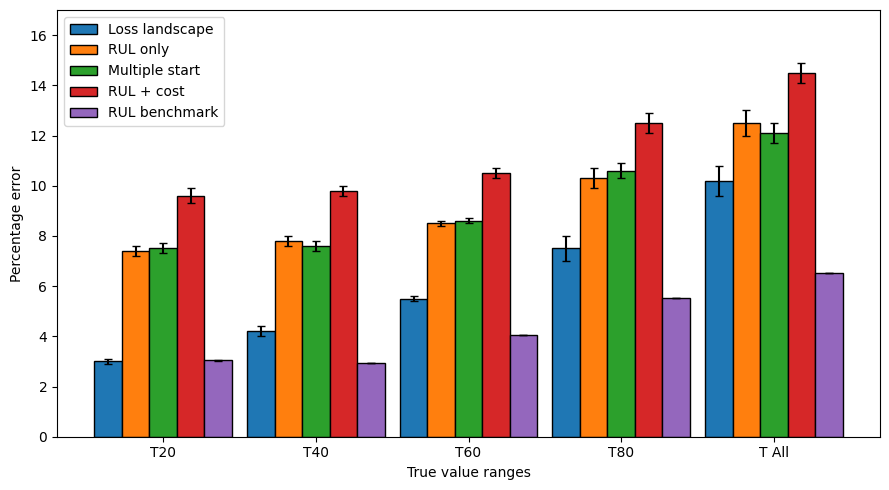

In [5]:
import numpy as np
import matplotlib.pyplot as plt

groups = ["T20", "T40", "T60", "T80", "T All"]
x = np.arange(len(groups))
width = 0.18

loss_landscape_mean = np.array([3.0, 4.2, 5.5, 7.5, 10.2])    # %
loss_landscape_std  = np.array([0.1, 0.2, 0.1, 0.5, 0.6])

rul_only_mean       = np.array([7.4, 7.8, 8.5, 10.3, 12.5])   # %
rul_only_std        = np.array([0.2, 0.2, 0.1, 0.4, 0.5])

multi_start_mean    = np.array([7.5, 7.6, 8.6, 10.6, 12.1])   # %
multi_start_std     = np.array([0.2, 0.2, 0.1, 0.3, 0.4])

rul_cost_mean       = np.array([9.6, 9.8, 10.5, 12.5, 14.5])  # %
rul_cost_std        = np.array([0.3, 0.2, 0.2, 0.4, 0.4])

new_pct = np.array([0.0304, 0.0293, 0.0405, 0.0553, 0.0651]) * 100
new_std = np.array([0.0068, 0.0044, 0.0060, 0.0085, 0.0048])

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x + 0*width, loss_landscape_mean, width, yerr=loss_landscape_std,
       label="Loss landscape", capsize=3, edgecolor='black')
ax.bar(x + 1*width, rul_only_mean,      width, yerr=rul_only_std,
       label="RUL only", capsize=3, edgecolor='black')
ax.bar(x + 2*width, multi_start_mean,   width, yerr=multi_start_std,
       label="Multiple start", capsize=3, edgecolor='black')
ax.bar(x + 3*width, rul_cost_mean,      width, yerr=rul_cost_std,
       label="RUL + cost", capsize=3, edgecolor='black')
ax.bar(x + 4*width, new_pct,            width, yerr=new_std,
       label="RUL benchmark", capsize=3, edgecolor='black')

ax.set_xticks(x + 2*width)
ax.set_xticklabels(groups)
ax.set_xlabel("True value ranges")
ax.set_ylabel("Percentage error")
ax.set_ylim(0, 17)             # adjust if your values exceed this
ax.legend(frameon=True, loc="upper left")
plt.tight_layout()
plt.show()
